# SOB4ES - XGBoost Multisalida
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook implementa **XGBoost con salida vectorial**, disponible desde la version 1.7 mediante el parametro `multi_strategy='multi_output_tree'`.

A diferencia del enfoque individual (un modelo por target), aqui un unico arbol de decision en cada iteracion del boosting aprende a predecir los 11 targets simultaneamente. Esto permite capturar correlaciones entre grupos biologicos de forma mas directa que entrenar modelos separados.

**Datasets utilizados:**
- `train.csv` - Entrenamiento (70 %, estratificado por pais)
- `test.csv`  - Tuning e hiperparametros (15 %)
- `eval.csv`  - Evaluacion final imparcial (15 %)

**Estructura del notebook:**
1. Configuracion
2. Carga de datos
3. Tuning de hiperparametros
4. Validacion cruzada
5. Importancia de variables
6. Entrenamiento de produccion
7. Evaluacion final

---
## 1. Configuracion del entorno


In [1]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
from pathlib import Path

import xgboost
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV, cross_validate, RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance

import itertools
from matplotlib.colors import LinearSegmentedColormap

import matplotlib.pyplot as plt
import shap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/xgb_multi/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path('output/var/').mkdir(parents=True, exist_ok=True)

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    #'cu_z',
    'k_z',
    'mo_z',
    #'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]
print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}
# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Librerias y variables cargadas correctamente...


In [2]:

# Deteccion de GPU / CUDA

# Comprueba si hay una GPU NVIDIA disponible y, en ese caso, configura
# XGBoost para usarla automaticamente. Si no hay GPU (o XGBoost no fue
# compilado con soporte CUDA), se usa la CPU sin que falle nada.

import subprocess

def _detectar_cuda():
    """Comprueba si hay una GPU NVIDIA con drivers CUDA disponibles en el sistema."""
    try:
        resultado = subprocess.run(
            ['nvidia-smi'],
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL,
            timeout=5,
        )
        return resultado.returncode == 0
    except (FileNotFoundError, subprocess.TimeoutExpired):
        return False

def _xgb_soporta_device():
    """XGBoost >= 2.0 usa el parametro 'device'; las versiones anteriores
    activan la GPU unicamente con tree_method='gpu_hist'."""
    try:
        return int(xgboost.__version__.split('.')[0]) >= 2
    except Exception:
        return False

CUDA_DISPONIBLE = _detectar_cuda()

if CUDA_DISPONIBLE and _xgb_soporta_device():
    # XGBoost >= 2.0: GPU via tree_method='hist' + device='cuda'
    XGB_DEVICE_PARAMS = {'tree_method': 'hist', 'device': 'cuda'}
elif CUDA_DISPONIBLE:
    # XGBoost < 2.0: GPU via tree_method='gpu_hist'
    XGB_DEVICE_PARAMS = {'tree_method': 'gpu_hist'}
else:
    XGB_DEVICE_PARAMS = {'tree_method': 'hist'}

print(f'GPU NVIDIA / CUDA detectada : {CUDA_DISPONIBLE}')
print(f'Version de XGBoost          : {xgboost.__version__}')
print(f'Parametros de dispositivo   : {XGB_DEVICE_PARAMS}')
if CUDA_DISPONIBLE:
    print('XGBoost usara la GPU para el tuning, la validacion y el entrenamiento de produccion.')
else:
    print('No se detecto GPU. XGBoost usara CPU (tree_method=\'hist\').')

# Ajuste automatico de n_jobs segun los nucleos disponibles
# Evita saturar la maquina (todos los procesos a la vez con n_jobs=-1)

def get_n_jobs(fraccion=0.75, reserva=1):
    """Calcula un n_jobs seguro dejando al menos `reserva` nucleos libres
    para que el sistema no se vuelva inutilizable durante la ejecucion."""
    n_cpu = os.cpu_count() or 1
    n_usar = max(1, min(int(n_cpu * fraccion), n_cpu - reserva))
    return n_usar

N_JOBS = get_n_jobs()
print(f'Nucleos disponibles: {os.cpu_count()} | n_jobs asignado: {N_JOBS}')

GPU NVIDIA / CUDA detectada : True
Version de XGBoost          : 3.3.0
Parametros de dispositivo   : {'tree_method': 'hist', 'device': 'cuda'}
XGBoost usara la GPU para el tuning, la validacion y el entrenamiento de produccion.
Nucleos disponibles: 20 | n_jobs asignado: 15


## 2. Carga de datos

Se cargan los tres datasets pre-generados (division 70/15/15, estratificada por pais).

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning / validacion cruzada              | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7.

In [3]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print('Cargando datasets...')
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados.")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")



Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados.
X_train: (299, 32)  |  X_test: (64, 32)  |  X_eval: (65, 32)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3. Busqueda de hiperparametros (Tuning)

El espacio de busqueda es identico al del XGBoost individual. El parametro `multi_strategy='multi_output_tree'` activa la salida vectorial: en lugar de construir un arbol por target (comportamiento por defecto), construye un unico arbol que predice todos los targets a la vez en cada iteracion del boosting.

El tuning se ejecuta por separado para cada uno de los 21 targets (`RandomizedSearchCV` sobre una columna a la vez) y los parametros optimos de cada target se combinan en un consenso ponderado por R2. Ese consenso es el que se aplica despues al modelo XGBoost multisalida.

Iniciando busqueda de hiperparametros (Tuning)...
Este proceso puede tardar bastante (ahora se evaluan los 21 targets).

[ 1/21] Buscando hiperparametros para: nematode_shannon_z
  R2: 0.2210  |  tiempo: 1.6 min
[ 2/21] Buscando hiperparametros para: macro_shannon_z
  R2: 0.3201  |  tiempo: 1.6 min
[ 3/21] Buscando hiperparametros para: earthworm_shannon_z
  R2: 0.4950  |  tiempo: 1.6 min
[ 4/21] Buscando hiperparametros para: orib_shannon_z
  R2: 0.0860  |  tiempo: 1.6 min
[ 5/21] Buscando hiperparametros para: meso_shannon_z
  R2: 0.1174  |  tiempo: 1.6 min
[ 6/21] Buscando hiperparametros para: coll_shannon_z
  R2: 0.2200  |  tiempo: 1.6 min
[ 7/21] Buscando hiperparametros para: bac_shannon_z
  R2: 0.1165  |  tiempo: 1.6 min
[ 8/21] Buscando hiperparametros para: fun_shannon_z
  R2: 0.0200  |  tiempo: 1.6 min
[ 9/21] Buscando hiperparametros para: euk_shannon_z
  R2: 0.2204  |  tiempo: 1.6 min
[10/21] Buscando hiperparametros para: oomy_shannon_z
  R2: 0.1587  |  tiempo: 1.6 min
[1

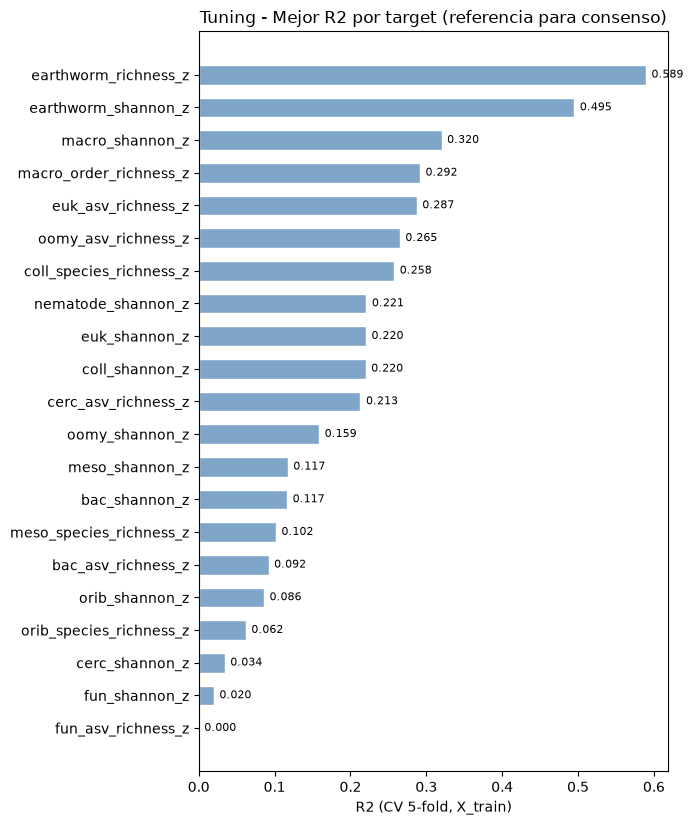

In [4]:
print("Iniciando busqueda de hiperparametros (Tuning)...")
print("Este proceso puede tardar bastante (ahora se evaluan los 21 targets).\n")

param_grid = {
	'n_estimators':     [50, 100, 150, 200, 300],
	'learning_rate':    [0.01, 0.02, 0.03, 0.05],
	'max_depth':        [2, 3, 4],
	'subsample':        [0.5, 0.6, 0.7, 0.8],
	'colsample_bytree': [0.5, 0.6, 0.7, 0.8],
	'min_child_weight': [5, 10, 15, 20],
	'gamma':            [0.2, 0.5, 1.0, 2.0],
	'reg_alpha':        [0.5, 1.0, 2.0, 5.0, 10.0],
	'reg_lambda':       [1.0, 2.0, 5.0, 10.0, 20.0],
	'scale_pos_weight': [1.0],
	'tree_method':      [XGB_DEVICE_PARAMS['tree_method']],
	'random_state':     [42],
}
if 'device' in XGB_DEVICE_PARAMS:
    param_grid['device'] = [XGB_DEVICE_PARAMS['device']]

resultados_tuning = {}

for idx, nombre_target in enumerate(TARGETS, 1):
    print(f"[{idx:2d}/{len(TARGETS)}] Buscando hiperparametros para: {nombre_target}")
    buscador = RandomizedSearchCV(
        estimator=XGBRegressor(**XGB_DEVICE_PARAMS, random_state=42),
        param_distributions=param_grid,
        n_iter=150,
        scoring='r2',
        cv=5,
        verbose=0,
        random_state=42,
        n_jobs= N_JOBS
    )
    start = time.time()
    buscador.fit(X_train, y_train[nombre_target].values)
    elapsed = (time.time() - start) / 60

    resultados_tuning[nombre_target] = {
        'params': buscador.best_params_,
        'r2':     buscador.best_score_,
    }
    print(f"  R2: {buscador.best_score_:.4f}  |  tiempo: {elapsed:.1f} min")

# Consenso de hiperparametros ponderado por R2 (ahora sobre los 21 targets)
r2_por_target = {t: max(resultados_tuning[t]['r2'], 0.0) for t in TARGETS}
suma_r2 = sum(r2_por_target.values())
if suma_r2 <= 0:
    pesos = {t: 1 / len(TARGETS) for t in TARGETS}
else:
    pesos = {t: v / suma_r2 for t, v in r2_por_target.items()}

print("\nCalculando consenso de hiperparametros (ponderado por R2 de los 21 targets)...")
for t in sorted(pesos, key=pesos.get, reverse=True)[:5]:
    print(f"  Peso {t:30}: {pesos[t]:.3f}")
print("  ...")

def consenso_int(key, default=0):
    return int(round(sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)))

def consenso_float(key, default=0.0):
    return sum(pesos[t] * resultados_tuning[t]['params'].get(key, default) for t in TARGETS)

def consenso_cat(key):
    mejor_target = max(pesos, key=pesos.get)
    return resultados_tuning[mejor_target]['params'][key]

def consenso_log(key):
    return float(np.exp(sum(pesos[t] * np.log(resultados_tuning[t]['params'][key]) for t in TARGETS)))

XGB_MULTI_PARAMS = {
    'n_estimators':      consenso_int('n_estimators'),
    'max_depth':         consenso_int('max_depth'),
    'learning_rate':     consenso_log('learning_rate'),
    'subsample':         consenso_float('subsample'),
    'colsample_bytree':  consenso_float('colsample_bytree'),
    'gamma':             consenso_float('gamma', 0.0),
    'min_child_weight':  consenso_int('min_child_weight'),
    'reg_alpha':         consenso_float('reg_alpha', 0.0),
    'reg_lambda':        consenso_float('reg_lambda', 1.0),
    'max_leaves':        consenso_int('max_leaves', 0),
    'scale_pos_weight':  1.0,    
    'random_state':      42,
}
XGB_MULTI_PARAMS.update(XGB_DEVICE_PARAMS)

print("\nHiperparametros consenso finales:")
for k, v in XGB_MULTI_PARAMS.items():
    print(f"  {k}: {v}")

# Grafico: R2 de tuning por target (ordenado)
_orden = sorted(r2_por_target, key=r2_por_target.get)
fig, ax = plt.subplots(figsize=(7, 0.35 * len(_orden) + 1))
_bars = ax.barh([t for t in _orden], [r2_por_target[t] for t in _orden], color=PALETTE['blue'], edgecolor='white', height=0.6)
ax.bar_label(_bars, fmt='{:.3f}', padding=4, fontsize=8)
ax.set_xlabel('R2 (CV 5-fold, X_train)')
ax.set_title('Tuning - Mejor R2 por target (referencia para consenso)', fontsize=12)
ax.axvline(0, color=PALETTE['gray'], linewidth=0.8)
plt.tight_layout()
plt.show()

## 4. Validacion cruzada

Se evalua la robustez con validacion cruzada repetida (5 pliegues x 3 repeticiones) sobre `X_train` con todos los targets a la vez. Se muestra el R2 promedio global y el R2 individual por target.

In [5]:
print('Validacion cruzada repetida sobre X_train (todos los targets)...\n')

cv_splitter = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
metricas    = ['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error']

modelo_cv = XGBRegressor(**XGB_MULTI_PARAMS)

print('-' * 65)
print('Target: MULTI-OUTPUT (Promedio de todos los targets - XGBoost)')
print('-' * 65)

resultados = cross_validate(
    estimator=modelo_cv,
    X=X_train, 
    y=y_train,
    cv=cv_splitter,
    scoring=metricas,
    return_train_score=True
)

r2_train = np.mean(resultados['train_r2'])
r2_cv    = np.mean(resultados['test_r2'])
r2_std   = np.std(resultados['test_r2'])
rmse_cv  = np.mean(-resultados['test_neg_root_mean_squared_error'])
mae_cv   = np.mean(-resultados['test_neg_mean_absolute_error'])

print(f'  Train R2          : {r2_train:.4f}')
print(f'  Validacion R2 (CV): {r2_cv:.4f} +/- {r2_std:.4f}')
print(f'  RMSE global       : {rmse_cv:.4f}')
print(f'  MAE global        : {mae_cv:.4f}')

diferencia = r2_train - r2_cv
if diferencia > 0.15:
    print(f'  Aviso: diferencia train/val = {diferencia:.4f}. Posible sobreajuste.\n')
else:
    print(f'  Diferencia train/val = {diferencia:.4f}. El modelo generaliza correctamente.\n')

# R2 individual por target (entrenando sobre todo X_train)
modelo_cv.fit(X_train, y_train)
y_pred_train = modelo_cv.predict(X_train)

print('  R2 individual por target (Evaluado en train):')
print('-' * 65)
for i, t in enumerate(TARGETS):
    # Aseguramos compatibilidad si y_train es un DataFrame de Pandas
    y_true_col = y_train.iloc[:, i] if hasattr(y_train, 'iloc') else y_train[:, i]
    r2 = r2_score(y_true_col, y_pred_train[:, i])
    print(f'    {t:30} {r2:.4f}')
print()

Validacion cruzada repetida sobre X_train (todos los targets)...

-----------------------------------------------------------------
Target: MULTI-OUTPUT (Promedio de todos los targets - XGBoost)
-----------------------------------------------------------------
  Train R2          : 0.7177
  Validacion R2 (CV): 0.1694 +/- 0.0347
  RMSE global       : 0.8884
  MAE global        : 0.6663
  Aviso: diferencia train/val = 0.5483. Posible sobreajuste.

  R2 individual por target (Evaluado en train):
-----------------------------------------------------------------
    nematode_shannon_z             0.7265
    macro_shannon_z                0.7537
    earthworm_shannon_z            0.8067
    orib_shannon_z                 0.6958
    meso_shannon_z                 0.7111
    coll_shannon_z                 0.7442
    bac_shannon_z                  0.6679
    fun_shannon_z                  0.6999
    euk_shannon_z                  0.7065
    oomy_shannon_z                 0.7081
    cerc_shannon

## 5. Importancia de variables

XGBoost expone directamente la importancia de cada variable mediante `feature_importances_`, que en modo multisalida refleja el impacto global sobre todos los targets. Se complementa con permutation importance para una estimacion mas fiable.

Calculando importancia de variables...

Calculando Permutation Importance (esto puede tardar un poco)...

Variables más relevantes exportadas en: './output/var/variables_mas_relevantes_xgb.csv'
Variables menos relevantes exportadas en: './output/var/variables_menos_relevantes_xgb.csv'

Top 10 variables por importancia (Ordenado por Permutación):
                       XGBoost gain  Permutacion (R2)
soil_ph_z                    0.0424            0.0757
p_z                          0.0306            0.0446
gee_temp_media_C_z           0.0402            0.0401
soil_moisture_z              0.0305            0.0364
dem_elevacion_m_z            0.0352            0.0337
eu_p_z                       0.0353            0.0308
eu_as_z                      0.0380            0.0303
k_z                          0.0262            0.0301
gee_humedad_rel_pct_z        0.0382            0.0294
silt_content_z               0.0346            0.0289


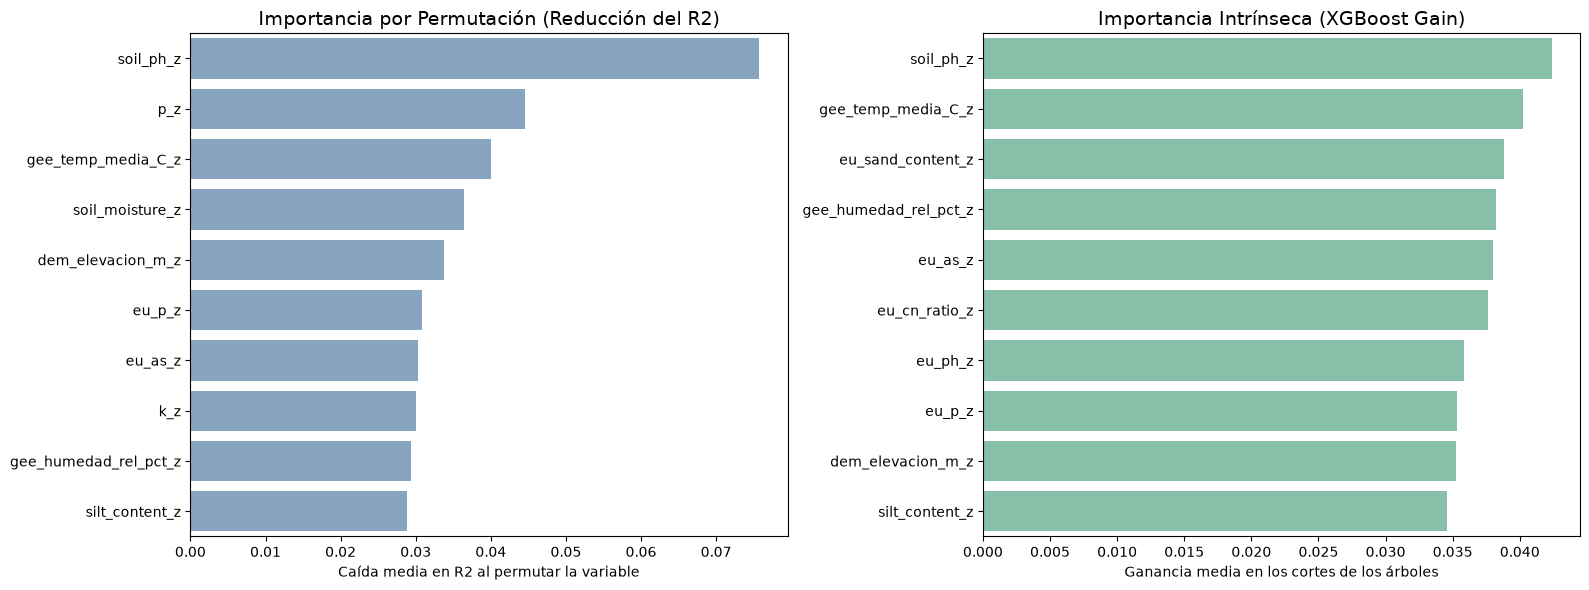


Top 10 variables menos relevantes (Ordenado por Permutación, ascendente):
                             XGBoost gain  Permutacion (R2)
total_plant_cover_z                0.0268            0.0099
eu_zn_z                            0.0290            0.0138
aggregate_stability_z              0.0248            0.0148
eu_organic_carbon_octop_z          0.0286            0.0169
eu_water_holding_capacity_z        0.0304            0.0181
eu_silt_content_z                  0.0343            0.0184
eu_sand_content_z                  0.0389            0.0189
clay_content_z                     0.0307            0.0193
eu_clay_content_z                  0.0342            0.0204
as_z                               0.0266            0.0217


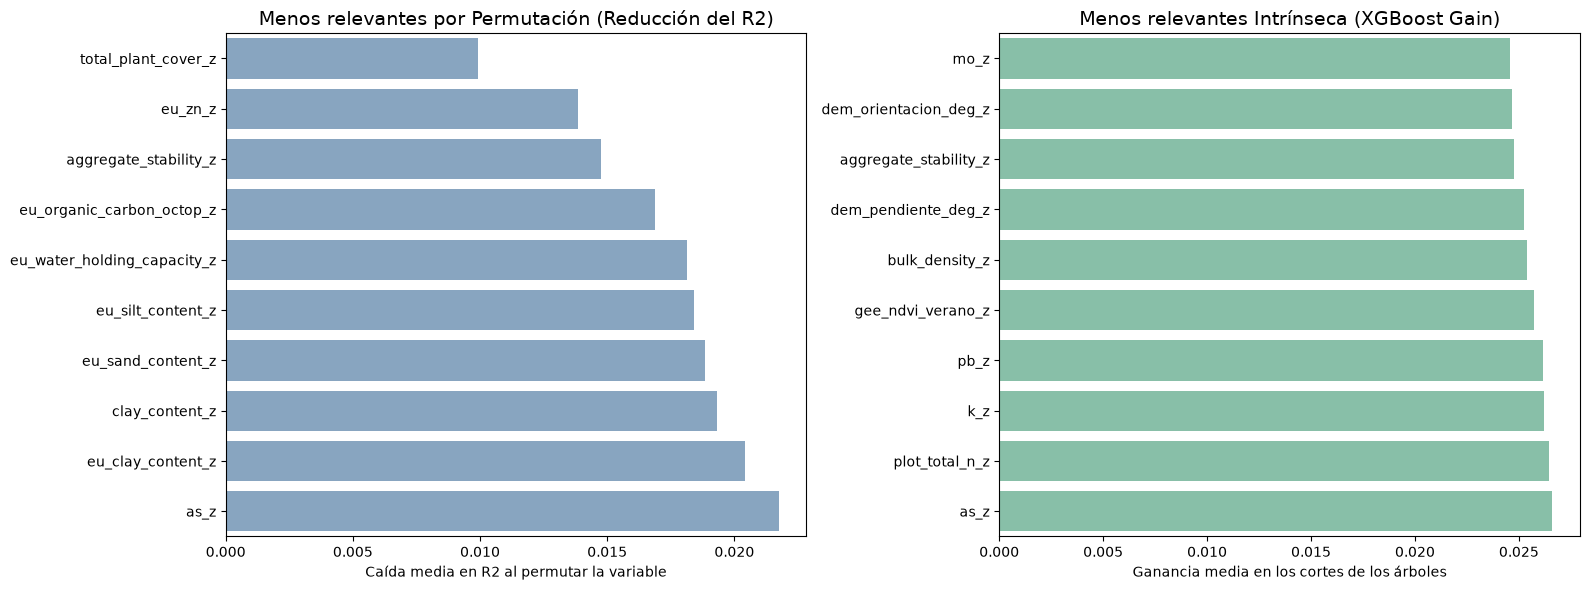


Calculando valores SHAP...
Variables más importantes para earthworm_shannon_z


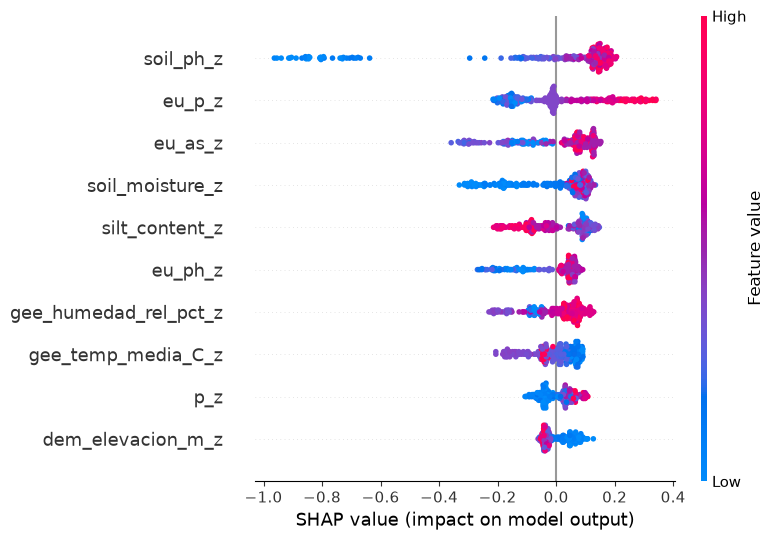

Variables más importantes para earthworm_richness_z


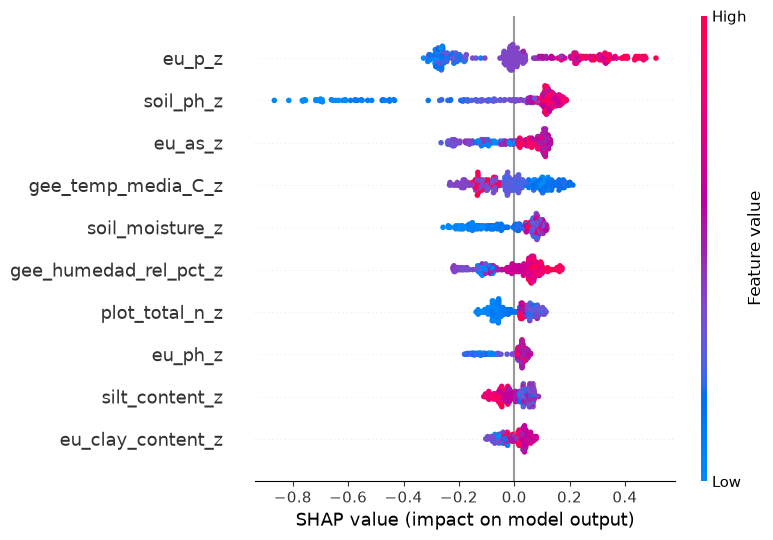

In [6]:
print('Calculando importancia de variables...\n')

# 1.- Cálculo de importancias

# Importancia intrinseca de XGBoost (gain medio por variable)
imp_xgb = pd.Series(modelo_cv.feature_importances_, index=FEATURES_AUTORIZADAS)

# Permutation importance sobre X_train
print('Calculando Permutation Importance (esto puede tardar un poco)...')
perm = permutation_importance(
    modelo_cv, X_train, y_train,
    n_repeats=10, random_state=42, n_jobs=-1
)
imp_perm = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)

# Unir en un DataFrame y extraer el Top 10
df_importancias = pd.DataFrame({
    'XGBoost gain': imp_xgb,
    'Permutacion (R2)': imp_perm
})

TOP_N = 10
top_features = df_importancias.sort_values('Permutacion (R2)', ascending=False).head(TOP_N)
bottom_features = df_importancias.sort_values('Permutacion (R2)', ascending=True).head(TOP_N)

# Exportar a CSV
ruta_top_csv = './output/var/variables_mas_relevantes_xgb.csv'
ruta_bottom_csv = './output/var/variables_menos_relevantes_xgb.csv'

top_features.to_csv(ruta_top_csv, index_label='variable')
bottom_features.to_csv(ruta_bottom_csv, index_label='variable')

print(f"\nVariables más relevantes exportadas en: '{ruta_top_csv}'")
print(f"Variables menos relevantes exportadas en: '{ruta_bottom_csv}'\n")

print(f'Top {TOP_N} variables por importancia (Ordenado por Permutación):')
print(top_features.round(4).to_string())

# 2.- Gráficos de barras (Permutación vs XGBoost Gain)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Permutación
sns.barplot(x=top_features['Permutacion (R2)'], y=top_features.index, ax=axes[0], color=PALETTE['blue'])
axes[0].set_title('Importancia por Permutación (Reducción del R2)', fontsize=14)
axes[0].set_xlabel('Caída media en R2 al permutar la variable')
axes[0].set_ylabel('')

# Gráfico B: XGBoost Gain 
top_features_gain = df_importancias.sort_values('XGBoost gain', ascending=False).head(TOP_N)
sns.barplot(x=top_features_gain['XGBoost gain'], y=top_features_gain.index, ax=axes[1], color=PALETTE['green'])
axes[1].set_title('Importancia Intrínseca (XGBoost Gain)', fontsize=14)
axes[1].set_xlabel('Ganancia media en los cortes de los árboles')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print(f'\nTop {TOP_N} variables menos relevantes (Ordenado por Permutación, ascendente):')
print(bottom_features.round(4).to_string())

# 2b.- Gráficos de barras variables menos relevantes (Permutación vs XGBoost Gain)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico A: Permutación (menos relevantes)
sns.barplot(x=bottom_features['Permutacion (R2)'], y=bottom_features.index, ax=axes[0], color=PALETTE['blue'])
axes[0].set_title('Menos relevantes por Permutación (Reducción del R2)', fontsize=14)
axes[0].set_xlabel('Caída media en R2 al permutar la variable')
axes[0].set_ylabel('')

# Gráfico B: XGBoost Gain (menos relevantes)
bottom_features_gain = df_importancias.sort_values('XGBoost gain', ascending=True).head(TOP_N)
sns.barplot(x=bottom_features_gain['XGBoost gain'], y=bottom_features_gain.index, ax=axes[1], color=PALETTE['green'])
axes[1].set_title('Menos relevantes Intrínseca (XGBoost Gain)', fontsize=14)
axes[1].set_xlabel('Ganancia media en los cortes de los árboles')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

# 3.- Análisis SHAP (Shannon y Richness)

print('\nCalculando valores SHAP...')

# Lista de targets que queremos analizar con SHAP
targets_shap = ['earthworm_shannon_z', 'earthworm_richness_z']

for target in targets_shap:
    print(f"Variables más importantes para {target}")
    
    # Entrenamos un modelo rápido de un solo target con los mismos parámetros base
    modelo_shap = XGBRegressor(random_state=42, n_jobs=-1, **XGB_DEVICE_PARAMS)

    # Intentamos copiar los hiperparámetros de los modelos generados
    try:
        if hasattr(modelo_cv, 'get_params'):
            modelo_shap.set_params(**modelo_cv.get_params())
    except Exception:
        pass # Si falla al copiar, usamos los parámetros base

    # Entrenamos solo con el target actual
    modelo_shap.fit(X_train, y_train[target])

    # Calculamos SHAP
    explainer = shap.TreeExplainer(modelo_shap)
    shap_values = explainer.shap_values(X_train)

    # Generamos el gráfico
    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, X_train, plot_type='dot', max_display=TOP_N, show=True)

## 6. Entrenamiento de produccion

Se entrena un ensamble de 5 modelos XGBoost multisalida, variando la semilla aleatoria. Cada modelo predice los 11 targets a la vez con `multi_strategy='multi_output_tree'`.

In [7]:
print('Entrenamiento de produccion (ensamble de 5 modelos XGBoost multisalida)...')
print('-' * 70)

global_start = time.time()
NUM_EXPERTOS = 5

for exp_id in range(NUM_EXPERTOS):
    t0     = time.time()
    params = XGB_MULTI_PARAMS.copy()
    params['random_state'] = 42 + exp_id

    # Entrenamos sobre y_train completo (matriz 11 targets)
    model  = XGBRegressor(**params)
    model.fit(X_train, y_train)

    joblib.dump(model, os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl'))
    print(f'  Modelo {exp_id+1}/5 completado ({time.time()-t0:.1f}s)')

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')


Entrenamiento de produccion (ensamble de 5 modelos XGBoost multisalida)...
----------------------------------------------------------------------
  Modelo 1/5 completado (1.9s)
  Modelo 2/5 completado (1.9s)
  Modelo 3/5 completado (1.9s)
  Modelo 4/5 completado (1.9s)
  Modelo 5/5 completado (1.9s)
----------------------------------------------------------------------
Produccion completada en 0.2 minutos.


## 7. Evaluacion final y prueba de funcionamiento

Esta seccion tiene dos partes:
1. **Evaluacion final:**
    Se mide por primera vez el rendimiento sobre `eval.csv`, el conjunto de datos que el modelo nunca ha visto. Al ser un modelo multisalida, se calculan las metricas globales (promedio sobre todos los targets) y tambien el R2 individual por target, para identificar cuales predice bien y cuales no.
2. **Prueba de funcionamiento (smoke test)**
    Se verificia que el pipeline funciona de extremo a extremo con 3 filas reales de `eval.csv`, comparando la prediccion con el valor real observado para cada target.


Evaluacion final sobre eval.csv (Ensamble XGBoost)
-----------------------------------------------------------------
  Target                               R2     RMSE      MAE
-----------------------------------------------------------------
  Global (Promedio)                0.0804   0.9186   0.6825
-----------------------------------------------------------------
  nematode_shannon_z               0.2163   0.8743   0.6795
  macro_shannon_z                  0.3795   0.7912   0.6492
  earthworm_shannon_z              0.5328   0.6823   0.4703
  orib_shannon_z                   0.2245   1.0070   0.8324
  meso_shannon_z                  -0.2826   1.1060   0.8786
  coll_shannon_z                  -0.3913   0.7473   0.5817
  bac_shannon_z                   -0.0142   1.0085   0.6866
  fun_shannon_z                   -0.0580   1.1768   0.9410
  euk_shannon_z                    0.0715   0.9345   0.6502
  oomy_shannon_z                   0.0700   1.0081   0.7294
  cerc_shannon_z               

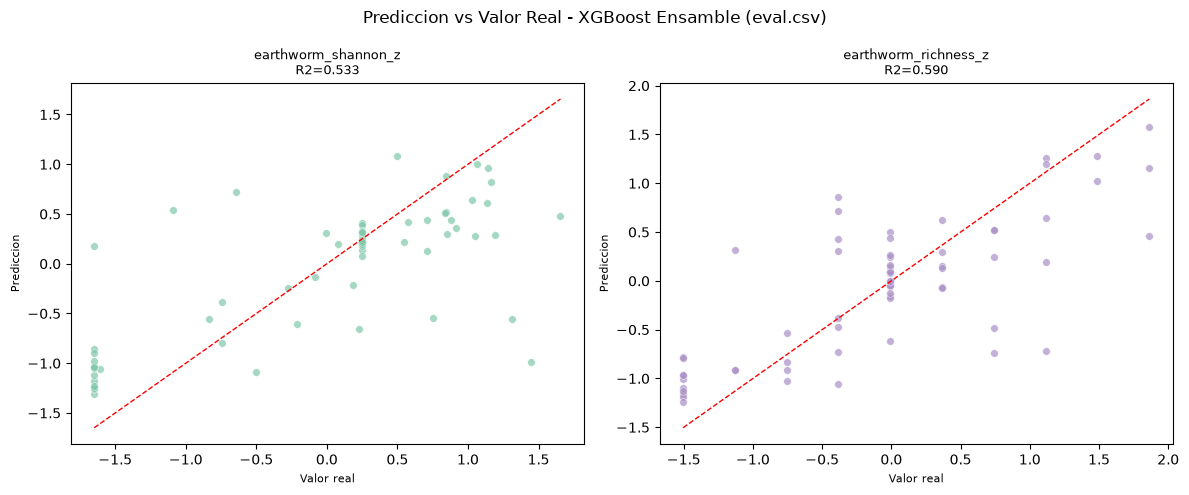

In [8]:
NUM_EXPERTOS = 5

# Evaluacion final
# Cargamos los 5 modelos expertos y promediamos sus predicciones sobre eval.csv.
print('Evaluacion final sobre eval.csv (Ensamble XGBoost)')
print('-' * 65)
print(f'  {"Target":30} {"R2":>8} {"RMSE":>8} {"MAE":>8}')
print('-' * 65)

preds_eval = []
for exp_id in range(NUM_EXPERTOS):
    ruta  = os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl')
    model = joblib.load(ruta)
    preds_eval.append(model.predict(X_eval))

# y_pred_eval es una matriz (n_muestras x len(TARGETS) targets)
y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

# Metricas globales
r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  {"Global (Promedio)":30} {r2_global:8.4f} {rmse_global:8.4f} {mae_global:8.4f}')
print('-' * 65)

# Metricas individuales por target
r2_por_target = r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')
for i, t in enumerate(TARGETS):
    rmse_t = np.sqrt(mean_squared_error(y_true_eval[:, i], y_pred_eval[:, i]))
    mae_t  = mean_absolute_error(y_true_eval[:, i], y_pred_eval[:, i])
    print(f'  {t:30} {r2_por_target[i]:8.4f} {rmse_t:8.4f} {mae_t:8.4f}')

print('-' * 65)

# Smoke test con datos reales
print('\nSmoke test - Inferencia con datos reales')
print('-' * 65)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    # Generamos y guardamos las predicciones de todos los modelos del ensamble
    votos = []
    for exp_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl')
        m     = joblib.load(ruta)
        votos.append(m.predict(df_new_data))

    # Promediamos para obtener el consenso final del ensamble
    consenso = np.mean(votos, axis=0)
    
    targets_smoke = ['earthworm_shannon_z', 'earthworm_richness_z']
    
    for tgt in targets_smoke:
        tgt_idx = TARGETS.index(tgt)
        print(f'\n  Target: {tgt}')
        print('  ' + '-' * 63)
        
        # Mostramos el voto de cada experto
        print('  Votos individuales por experto:')
        for exp_id in range(NUM_EXPERTOS):
            pred_experto = votos[exp_id]
            print(f'    Modelo {exp_id+1} | '
                  f'Fila {indices_elegidos[0]}: {pred_experto[0, tgt_idx]:>7.4f} | '
                  f'Fila {indices_elegidos[1]}: {pred_experto[1, tgt_idx]:>7.4f} | '
                  f'Fila {indices_elegidos[2]}: {pred_experto[2, tgt_idx]:>7.4f}')
        
        print('  ' + '-' * 63)
        print('  Consenso final frente a valores reales:')
        for i, idx in enumerate(indices_elegidos):
            pred_val = consenso[i, tgt_idx]
            real_val = y_eval.loc[idx, tgt]
            error    = abs(pred_val - real_val)
            print(f'    Fila {idx:<4} | Consenso: {pred_val:>7.4f} | '
                  f'Valor Real: {real_val:>7.4f} | Error: {error:>6.4f}')

    print('\n' + '-' * 65)
    print('Smoke test superado. El pipeline XGBoost multisalida funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')

# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    
    preds = []
    for exp_id in range(NUM_EXPERTOS):
        ruta  = os.path.join(MODELS_DIR, f'xgb_multi_exp{exp_id}.pkl')
        preds.append(joblib.load(ruta).predict(X_eval))
    
    yp = np.mean(preds, axis=0)[:, idx_col]
    yt = y_eval[tgt].values
    
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
    
plt.suptitle('Prediccion vs Valor Real - XGBoost Ensamble (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()